In [96]:
import json

In [97]:
class_name = "animal"

In [98]:
def convert_bbox_to_locations(bbox, width, height):
    x_min, y_min, box_width, box_height = bbox
    x_min, y_min, box_width, box_height = int(x_min), int(y_min), int(box_width), int(box_height)

    x_max = x_min + box_width
    y_max = y_min + box_height
    
    x_min_token = int((x_min / width) * 1000)
    y_min_token = int((y_min / height) * 1000)
    x_max_token = int((x_max / width) * 1000)
    y_max_token = int((y_max / height) * 1000)

    return f"{class_name}<loc_{x_min_token}><loc_{y_min_token}><loc_{x_max_token}><loc_{y_max_token}>"

In [99]:
def convert_format(annotations_data):
    converted_data = []
    
    images = annotations_data['images']
    annotations = annotations_data['annotations']
    
    for img in images:
        img_id = img['id']
        img_name = img['file_name']
        img_width = img['width']
        img_height = img['height']
        
        img_annotations = [ann for ann in annotations if ann['image_id'] == img_id]

        bbox_tokens = []
        for ann in img_annotations:
            bbox = ann['bbox']
            location_token = convert_bbox_to_locations(bbox, img_width, img_height)
            bbox_tokens.append(location_token)

        suffix = "".join(bbox_tokens)

        converted_entry = {
            "image": img_name,
            "prefix": "<OD>",
            "suffix": suffix
        }
        converted_data.append(converted_entry)
    
    return converted_data

In [100]:
def save_to_jsonl(data, filepath):
    with open(filepath, 'w') as f:
        for entry in data:
            f.write(json.dumps(entry) + '\n')

In [103]:
def main():
    train_annotations_path = "train_annotations.json"
    val_annotations_path = "val_annotations.json"
    
    with open(train_annotations_path, 'r') as f:
        train_annotations = json.load(f)

    with open(val_annotations_path, 'r') as f:
        val_annotations = json.load(f)

    train_data = convert_format(train_annotations)
    val_data = convert_format(val_annotations)

    save_to_jsonl(train_data, "train/annotations.jsonl")
    save_to_jsonl(val_data, "valid/annotations.jsonl")

In [104]:
if __name__ == "__main__":
    main()

: 

## Визуализируем полученные данные

In [91]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import json

In [92]:
def parse_suffix(suffix, width, height):
    locs = []
    tokens = suffix.split("<loc_")[1:]
    
    for token in tokens:
        loc = int(token.split(">")[0])
        locs.append(loc)

    boxes = []
    for i in range(0, len(locs), 4):
        if i + 3 < len(locs):
            x_min = locs[i]
            y_min = locs[i + 1]
            x_max = locs[i + 2]
            y_max = locs[i + 3]

            x = int((x_min / 1000) * width)
            y = int((y_min / 1000) * height)
            box_width = int((x_max / 1000) * width) - x
            box_height = int((y_max / 1000) * height) - y

            boxes.append((x, y, box_width, box_height))

    return boxes

In [93]:
def draw_boxes(ax, boxes):
    for (x, y, box_width, box_height) in boxes:
        rect = plt.Rectangle((x, y), box_width, box_height,
                             linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

In [94]:
def visualize_random_images(filepath, image_folder, num_images=20):
    images_data = []

    with open(filepath, 'r') as f:
        for line in f:
            images_data.append(json.loads(line))

    sampled_data = random.sample(images_data, num_images)

    fig, axs = plt.subplots(4, 5, figsize=(20, 16))
    axs = axs.flatten()

    for ax, data in zip(axs, sampled_data):
        img_path = f"{image_folder}/{data['image']}"
        try:
            img = Image.open(img_path)
            ax.imshow(img)

            width, height = img.size
            
            boxes = parse_suffix(data['suffix'], width, height)

            draw_boxes(ax, boxes)
            ax.axis('off')
        except FileNotFoundError:
            print(f"Файл не найден: {img_path}")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

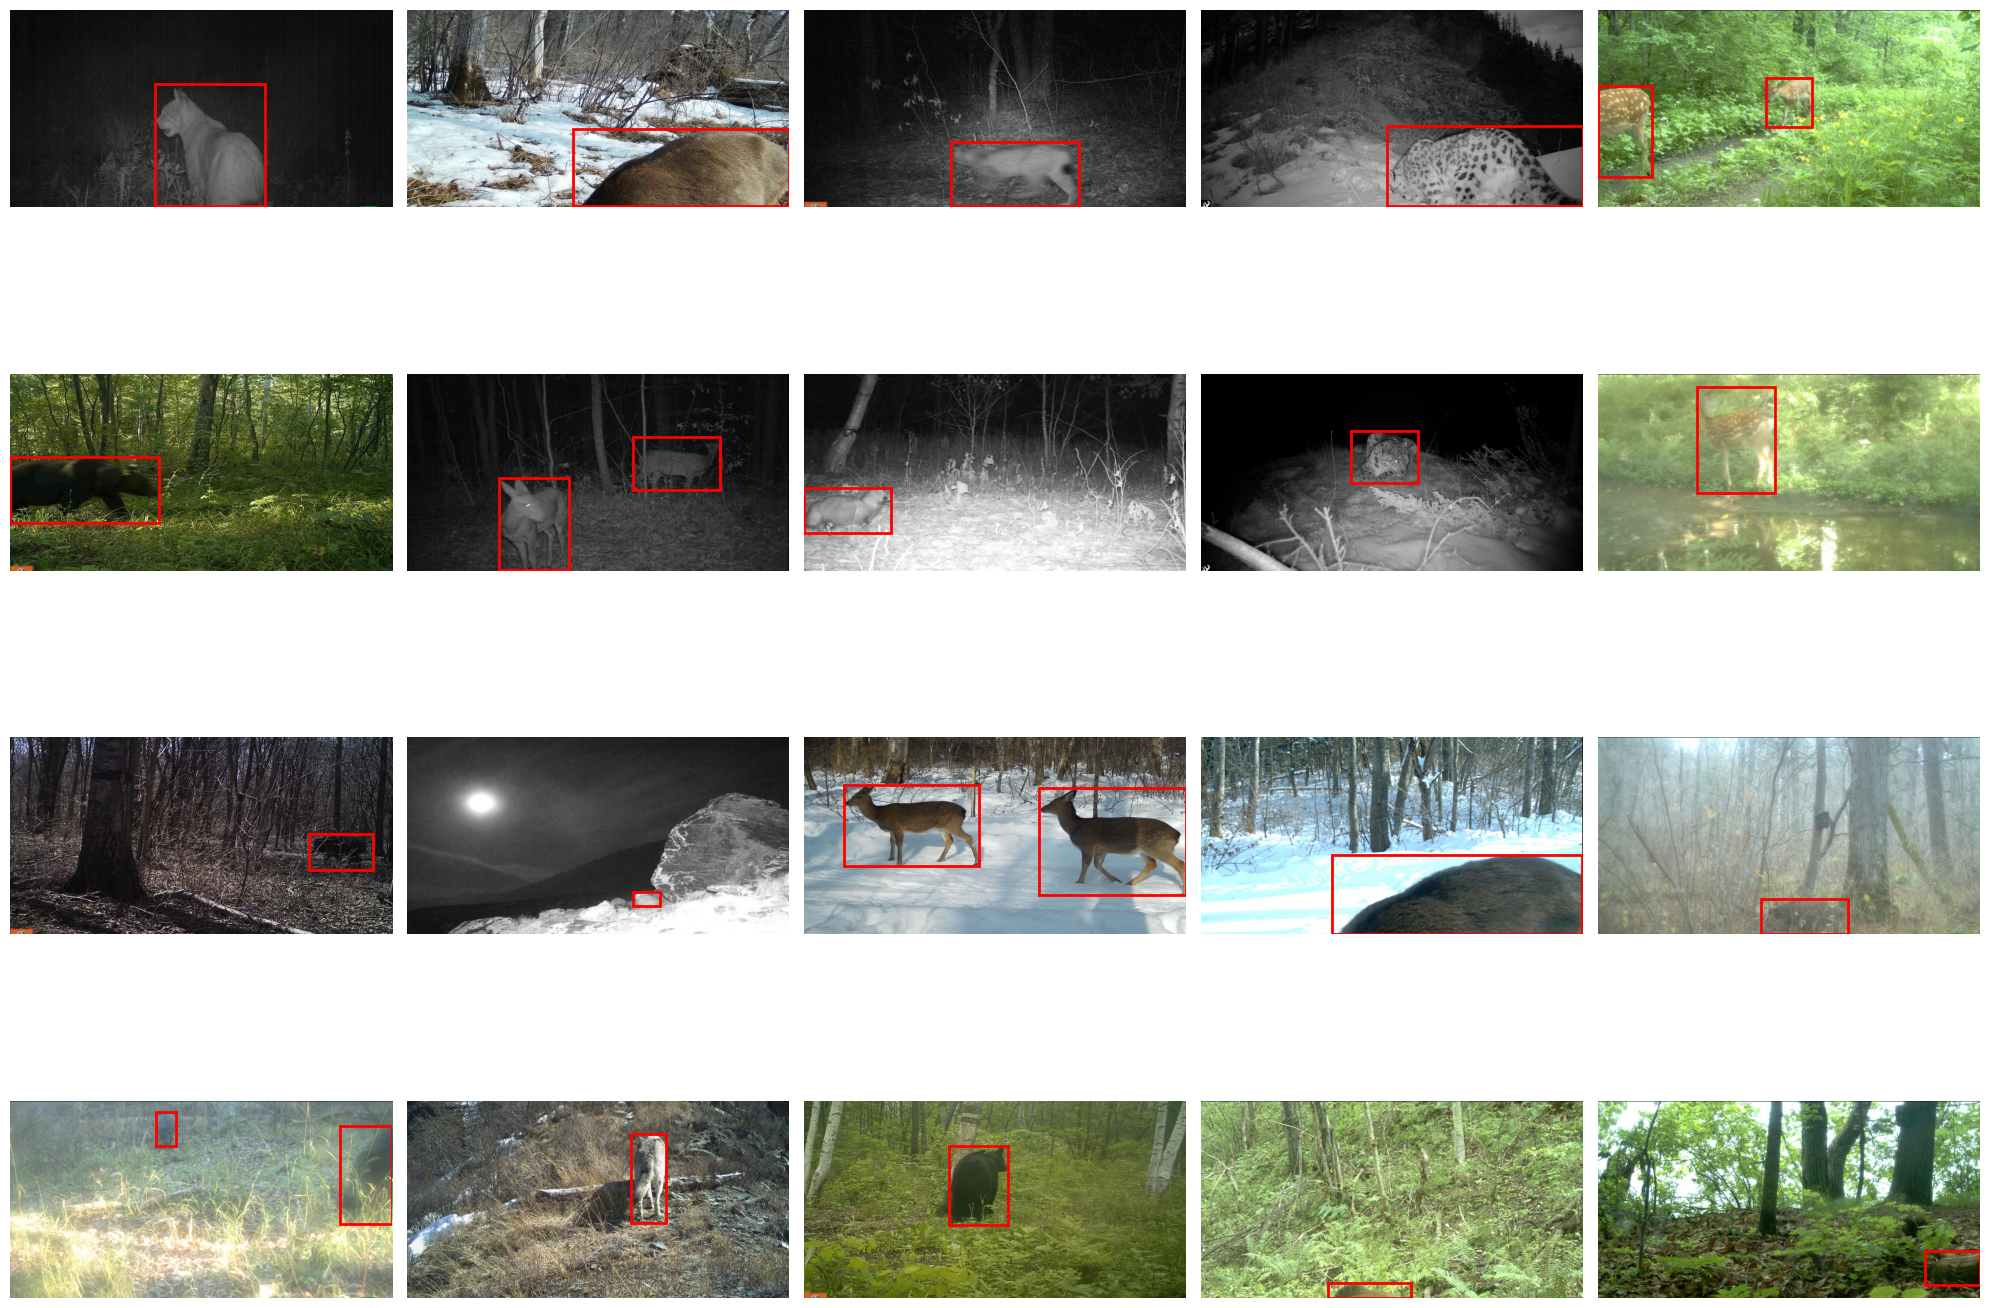

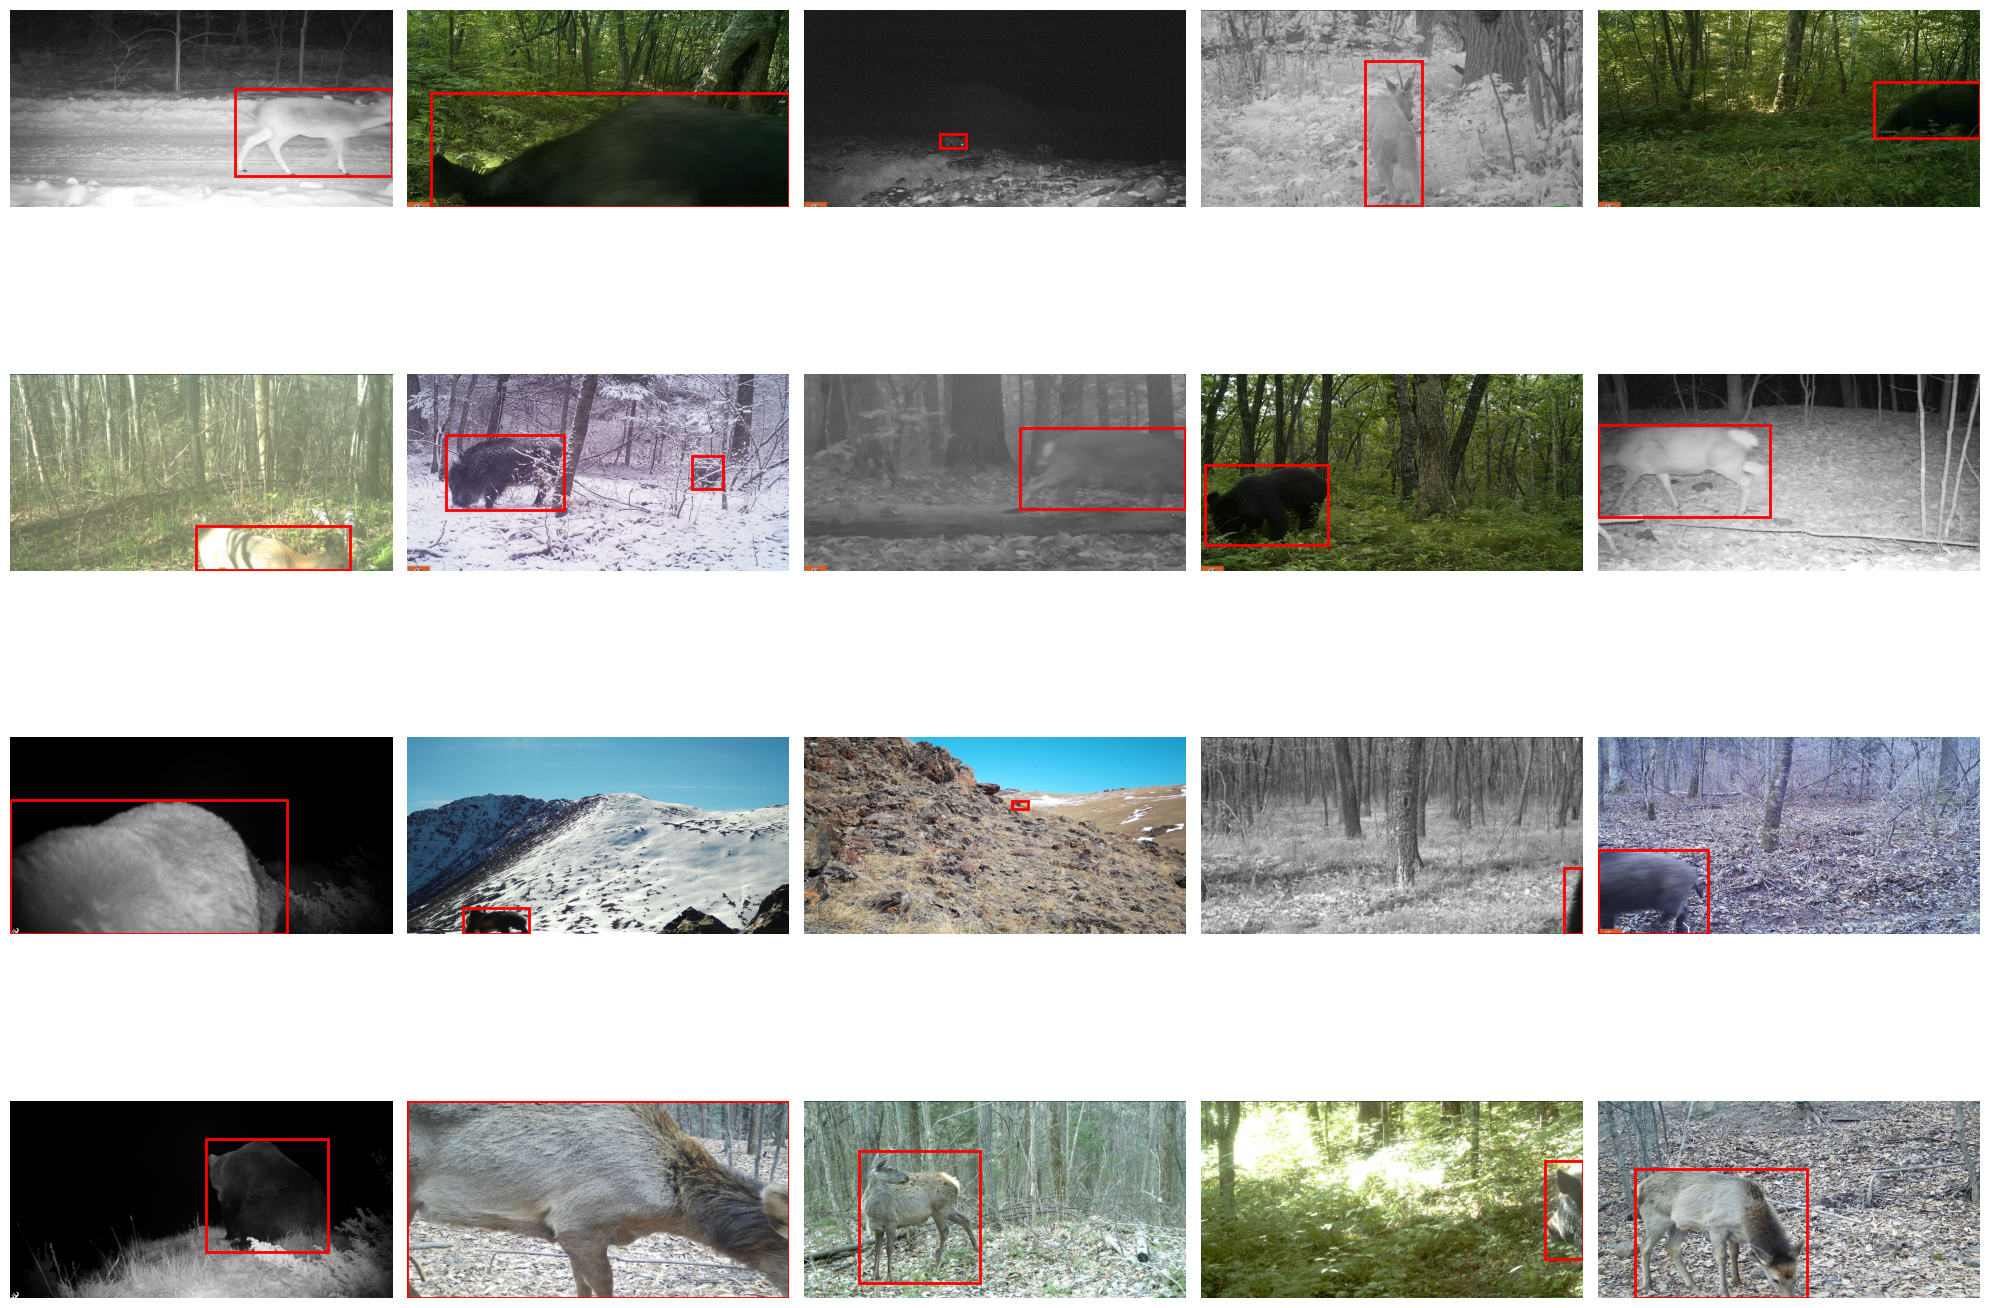

In [95]:
if __name__ == "__main__":
    visualize_random_images("train_data.jsonl", "train")
    visualize_random_images("val_data.jsonl", "val")